<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_C/Exp%205%20-%20Support%20Vector%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




*   This code implements a Support Vector Regression (SVR) model to predict housing prices (MEDV) using three features: RM (average number of rooms), AGE (age of the house), and TAX (property tax rate).

*   It first handles missing values using mean imputation and standardizes both features and target values. The data is then split into training and test sets, and an SVR model with an RBF kernel is trained.
*   Predictions are made on the test set, and the results are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. Finally, it visualizes the actual vs predicted prices, showing how well the model performs.









Original shapes -> X: (506, 3) , y: (506,)
After scaling -> X: (506, 3) , y: (506,)
Mean Absolute Error (MAE): 2.850
Root Mean Squared Error (RMSE): 4.922
R² Score: 0.670


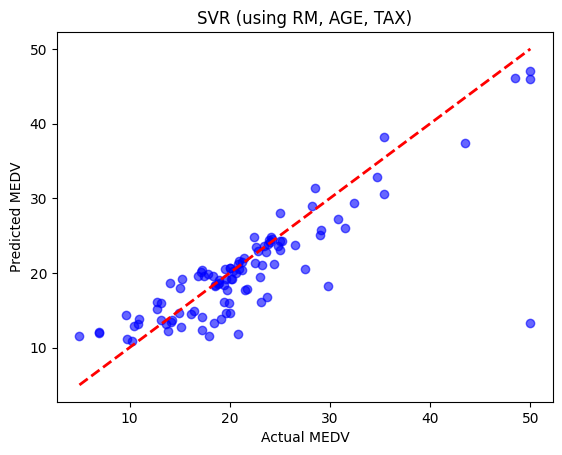

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load dataset
dataset = pd.read_csv('HousingData.csv')

# Keep only selected features (RM, AGE, TAX) and target (MEDV)
X = dataset[['RM', 'AGE', 'TAX']].values
y = dataset['MEDV'].values   # assuming last column is MEDV (house price)

print("Original shapes -> X:", X.shape, ", y:", y.shape)

# Step 1: Handle missing values
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Step 2: Feature scaling
sc_X = StandardScaler()
sc_y = StandardScaler()

X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y.reshape(-1, 1)).ravel()

print("After scaling -> X:", X.shape, ", y:", y.shape)

# Step 3: Train/test split (20% test data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Train SVR model
regressor = SVR(kernel="rbf")
regressor.fit(X_train, y_train)

# Step 5: Predictions on test set
y_pred_test = regressor.predict(X_test)

# Inverse transform predictions and actuals
y_pred_test_orig = sc_y.inverse_transform(y_pred_test.reshape(-1, 1))
y_test_orig = sc_y.inverse_transform(y_test.reshape(-1, 1))

# Step 6: Evaluation metrics
# Step 6: Evaluation metrics
mae = mean_absolute_error(y_test_orig, y_pred_test_orig)
mse = mean_squared_error(y_test_orig, y_pred_test_orig)
rmse = np.sqrt(mse)   # RMSE for old sklearn
r2 = r2_score(y_test_orig, y_pred_test_orig)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² Score: {r2:.3f}")


# Step 7: Visualization - Actual vs Predicted
plt.scatter(y_test_orig, y_pred_test_orig, color='blue', alpha=0.6)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         color='red', linestyle='--', linewidth=2)  # perfect prediction line
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("SVR (using RM, AGE, TAX)")
plt.show()


# **SVR using Linear Kernel**

This code compares SVR (linear kernel) and Linear Regression for predicting housing prices. Data is preprocessed, split, models are trained, evaluated (MAE, RMSE, R²), and results are visualized with actual vs. predicted plots.

Original shapes -> X: (506, 3) , y: (506,)
After scaling -> X: (506, 3) , y: (506,)

--- Model Comparison ---
SVR  -> MAE: 3.642, RMSE: 5.635, R²: 0.574
Linear Regression -> MAE: 3.825, RMSE: 5.623, R²: 0.576


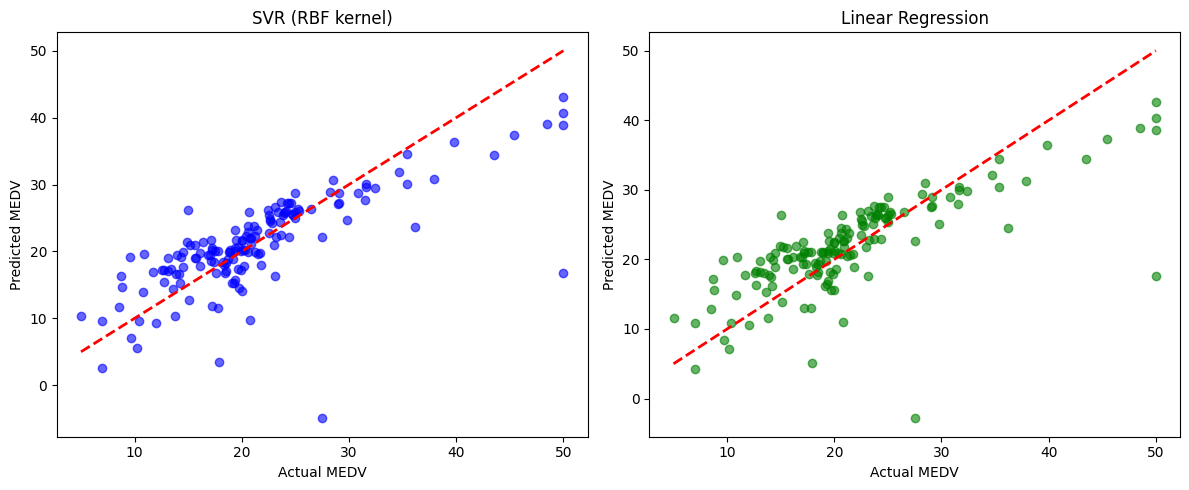

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load dataset
dataset = pd.read_csv('HousingData.csv')

# Keep only selected features (RM, AGE, TAX) and target (MEDV)
X = dataset[['RM', 'AGE', 'TAX']].values
y = dataset['MEDV'].values   # assuming last column is MEDV (house price)

print("Original shapes -> X:", X.shape, ", y:", y.shape)

# Step 1: Handle missing values
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Step 2: Feature scaling
sc_X = StandardScaler()
sc_y = StandardScaler()

X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y.reshape(-1, 1)).ravel()

print("After scaling -> X:", X.shape, ", y:", y.shape)

# Step 3: Train/test split (20% test data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ---------------- SVR Model ----------------
svr_regressor = SVR(kernel="linear")
svr_regressor.fit(X_train, y_train)

y_pred_svr = svr_regressor.predict(X_test)

# Inverse transform
y_pred_svr_orig = sc_y.inverse_transform(y_pred_svr.reshape(-1, 1))
y_test_orig = sc_y.inverse_transform(y_test.reshape(-1, 1))

# Metrics for SVR
mae_svr = mean_absolute_error(y_test_orig, y_pred_svr_orig)
rmse_svr = np.sqrt(mean_squared_error(y_test_orig, y_pred_svr_orig))
r2_svr = r2_score(y_test_orig, y_pred_svr_orig)

# ---------------- Linear Regression Model ----------------
lin_regressor = LinearRegression()
lin_regressor.fit(X_train, y_train)

y_pred_lin = lin_regressor.predict(X_test)

# Inverse transform
y_pred_lin_orig = sc_y.inverse_transform(y_pred_lin.reshape(-1, 1))

# Metrics for Linear Regression
mae_lin = mean_absolute_error(y_test_orig, y_pred_lin_orig)
rmse_lin = np.sqrt(mean_squared_error(y_test_orig, y_pred_lin_orig))
r2_lin = r2_score(y_test_orig, y_pred_lin_orig)

# ---------------- Print Results ----------------
print("\n--- Model Comparison ---")
print(f"SVR  -> MAE: {mae_svr:.3f}, RMSE: {rmse_svr:.3f}, R²: {r2_svr:.3f}")
print(f"Linear Regression -> MAE: {mae_lin:.3f}, RMSE: {rmse_lin:.3f}, R²: {r2_lin:.3f}")

# ---------------- Visualization ----------------
plt.figure(figsize=(12, 5))

# SVR plot
plt.subplot(1, 2, 1)
plt.scatter(y_test_orig, y_pred_svr_orig, color='blue', alpha=0.6)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("SVR (RBF kernel)")

# Linear Regression plot
plt.subplot(1, 2, 2)
plt.scatter(y_test_orig, y_pred_lin_orig, color='green', alpha=0.6)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Linear Regression")

plt.tight_layout()
plt.show()


SVR Linear with linear regression
--- Model Comparison ---
SVR  -> MAE: 3.642, RMSE: 5.635, R²: 0.574
Linear Regression -> MAE: 3.825, RMSE: 5.623, R²: 0.576


SVR RBF with linear regression
--- Model Comparison ---
SVR  -> MAE: 2.794, RMSE: 4.572, R²: 0.719
Linear Regression -> MAE: 3.825, RMSE: 5.623, R²: 0.576

# **SVR using RBF kernel**

This code predicts housing prices using SVR (RBF kernel) and Linear Regression, comparing their performance with error metrics and scatter plots of actual vs. predicted values. Insight: SVR handles non-linear patterns better, while Linear Regression assumes a straight-line relationship.

Original shapes -> X: (506, 3) , y: (506,)
After scaling -> X: (506, 3) , y: (506,)

--- Model Comparison ---
SVR  -> MAE: 2.794, RMSE: 4.572, R²: 0.719
Linear Regression -> MAE: 3.825, RMSE: 5.623, R²: 0.576


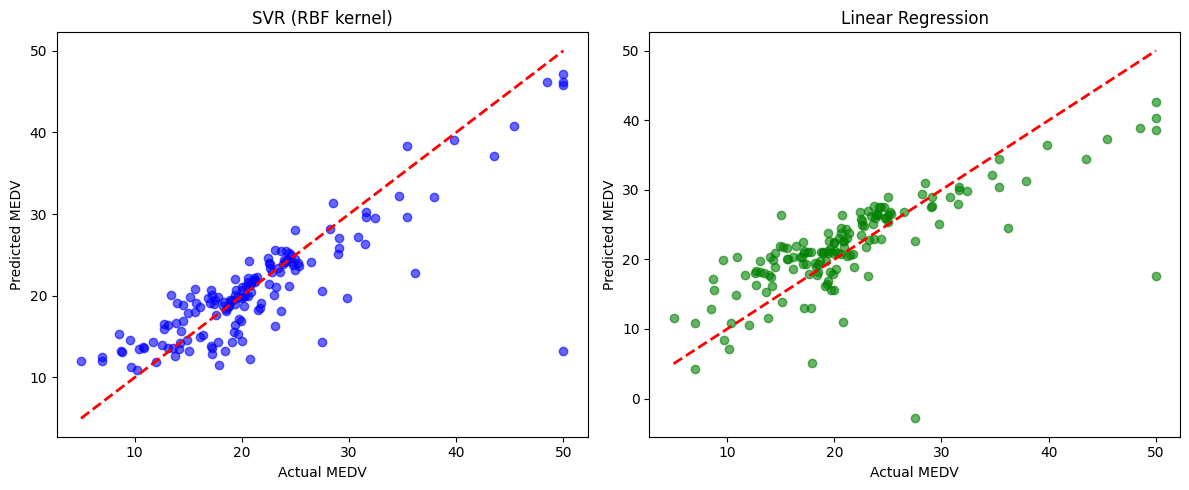

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load dataset
dataset = pd.read_csv('HousingData.csv')

# Keep only selected features (RM, AGE, TAX) and target (MEDV)
X = dataset[['RM', 'AGE', 'TAX']].values
y = dataset['MEDV'].values   # assuming last column is MEDV (house price)

print("Original shapes -> X:", X.shape, ", y:", y.shape)

# Step 1: Handle missing values
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Step 2: Feature scaling
sc_X = StandardScaler()
sc_y = StandardScaler()

X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y.reshape(-1, 1)).ravel()

print("After scaling -> X:", X.shape, ", y:", y.shape)

# Step 3: Train/test split (20% test data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ---------------- SVR Model ----------------
svr_regressor = SVR(kernel="rbf")
svr_regressor.fit(X_train, y_train)

y_pred_svr = svr_regressor.predict(X_test)

# Inverse transform
y_pred_svr_orig = sc_y.inverse_transform(y_pred_svr.reshape(-1, 1))
y_test_orig = sc_y.inverse_transform(y_test.reshape(-1, 1))

# Metrics for SVR
mae_svr = mean_absolute_error(y_test_orig, y_pred_svr_orig)
rmse_svr = np.sqrt(mean_squared_error(y_test_orig, y_pred_svr_orig))
r2_svr = r2_score(y_test_orig, y_pred_svr_orig)

# ---------------- Linear Regression Model ----------------
lin_regressor = LinearRegression()
lin_regressor.fit(X_train, y_train)

y_pred_lin = lin_regressor.predict(X_test)

# Inverse transform
y_pred_lin_orig = sc_y.inverse_transform(y_pred_lin.reshape(-1, 1))

# Metrics for Linear Regression
mae_lin = mean_absolute_error(y_test_orig, y_pred_lin_orig)
rmse_lin = np.sqrt(mean_squared_error(y_test_orig, y_pred_lin_orig))
r2_lin = r2_score(y_test_orig, y_pred_lin_orig)

# ---------------- Print Results ----------------
print("\n--- Model Comparison ---")
print(f"SVR  -> MAE: {mae_svr:.3f}, RMSE: {rmse_svr:.3f}, R²: {r2_svr:.3f}")
print(f"Linear Regression -> MAE: {mae_lin:.3f}, RMSE: {rmse_lin:.3f}, R²: {r2_lin:.3f}")

# ---------------- Visualization ----------------
plt.figure(figsize=(12, 5))

# SVR plot
plt.subplot(1, 2, 1)
plt.scatter(y_test_orig, y_pred_svr_orig, color='blue', alpha=0.6)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("SVR (RBF kernel)")

# Linear Regression plot
plt.subplot(1, 2, 2)
plt.scatter(y_test_orig, y_pred_lin_orig, color='green', alpha=0.6)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Linear Regression")

plt.tight_layout()
plt.show()


# **SVR using Sigmoid kernel**

This code predicts housing prices using SVR (sigmoid kernel) and Linear Regression, evaluating them with MAE, RMSE, and R² along with actual vs. predicted plots. Insight: The sigmoid kernel in SVR often struggles with regression tasks, so Linear Regression may provide more stable results here.

Original shapes -> X: (506, 3) , y: (506,)
After scaling -> X: (506, 3) , y: (506,)

--- Model Comparison ---
SVR  -> MAE: 47.555, RMSE: 82.969, R²: -91.385
Linear Regression -> MAE: 3.825, RMSE: 5.623, R²: 0.576


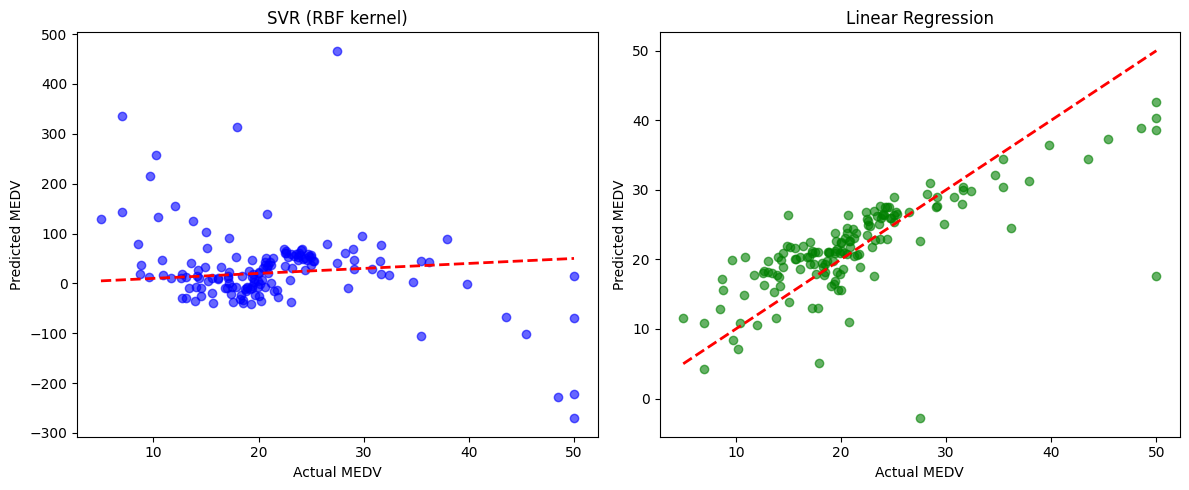

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load dataset
dataset = pd.read_csv('HousingData.csv')

# Keep only selected features (RM, AGE, TAX) and target (MEDV)
X = dataset[['RM', 'AGE', 'TAX']].values
y = dataset['MEDV'].values   # assuming last column is MEDV (house price)

print("Original shapes -> X:", X.shape, ", y:", y.shape)

# Step 1: Handle missing values
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Step 2: Feature scaling
sc_X = StandardScaler()
sc_y = StandardScaler()

X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y.reshape(-1, 1)).ravel()

print("After scaling -> X:", X.shape, ", y:", y.shape)

# Step 3: Train/test split (20% test data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ---------------- SVR Model ----------------
svr_regressor = SVR(kernel="sigmoid")
svr_regressor.fit(X_train, y_train)

y_pred_svr = svr_regressor.predict(X_test)

# Inverse transform
y_pred_svr_orig = sc_y.inverse_transform(y_pred_svr.reshape(-1, 1))
y_test_orig = sc_y.inverse_transform(y_test.reshape(-1, 1))

# Metrics for SVR
mae_svr = mean_absolute_error(y_test_orig, y_pred_svr_orig)
rmse_svr = np.sqrt(mean_squared_error(y_test_orig, y_pred_svr_orig))
r2_svr = r2_score(y_test_orig, y_pred_svr_orig)

# ---------------- Linear Regression Model ----------------
lin_regressor = LinearRegression()
lin_regressor.fit(X_train, y_train)

y_pred_lin = lin_regressor.predict(X_test)

# Inverse transform
y_pred_lin_orig = sc_y.inverse_transform(y_pred_lin.reshape(-1, 1))

# Metrics for Linear Regression
mae_lin = mean_absolute_error(y_test_orig, y_pred_lin_orig)
rmse_lin = np.sqrt(mean_squared_error(y_test_orig, y_pred_lin_orig))
r2_lin = r2_score(y_test_orig, y_pred_lin_orig)

# ---------------- Print Results ----------------
print("\n--- Model Comparison ---")
print(f"SVR  -> MAE: {mae_svr:.3f}, RMSE: {rmse_svr:.3f}, R²: {r2_svr:.3f}")
print(f"Linear Regression -> MAE: {mae_lin:.3f}, RMSE: {rmse_lin:.3f}, R²: {r2_lin:.3f}")

# ---------------- Visualization ----------------
plt.figure(figsize=(12, 5))

# SVR plot
plt.subplot(1, 2, 1)
plt.scatter(y_test_orig, y_pred_svr_orig, color='blue', alpha=0.6)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("SVR (RBF kernel)")

# Linear Regression plot
plt.subplot(1, 2, 2)
plt.scatter(y_test_orig, y_pred_lin_orig, color='green', alpha=0.6)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Linear Regression")

plt.tight_layout()
plt.show()


# **Feature vs Predicted Plots**

This code plots predicted housing prices (MEDV) against each feature (RM, AGE, TAX) for both SVR and Linear Regression. Insight: Such feature-wise plots help compare how each model captures relationships with individual predictors.

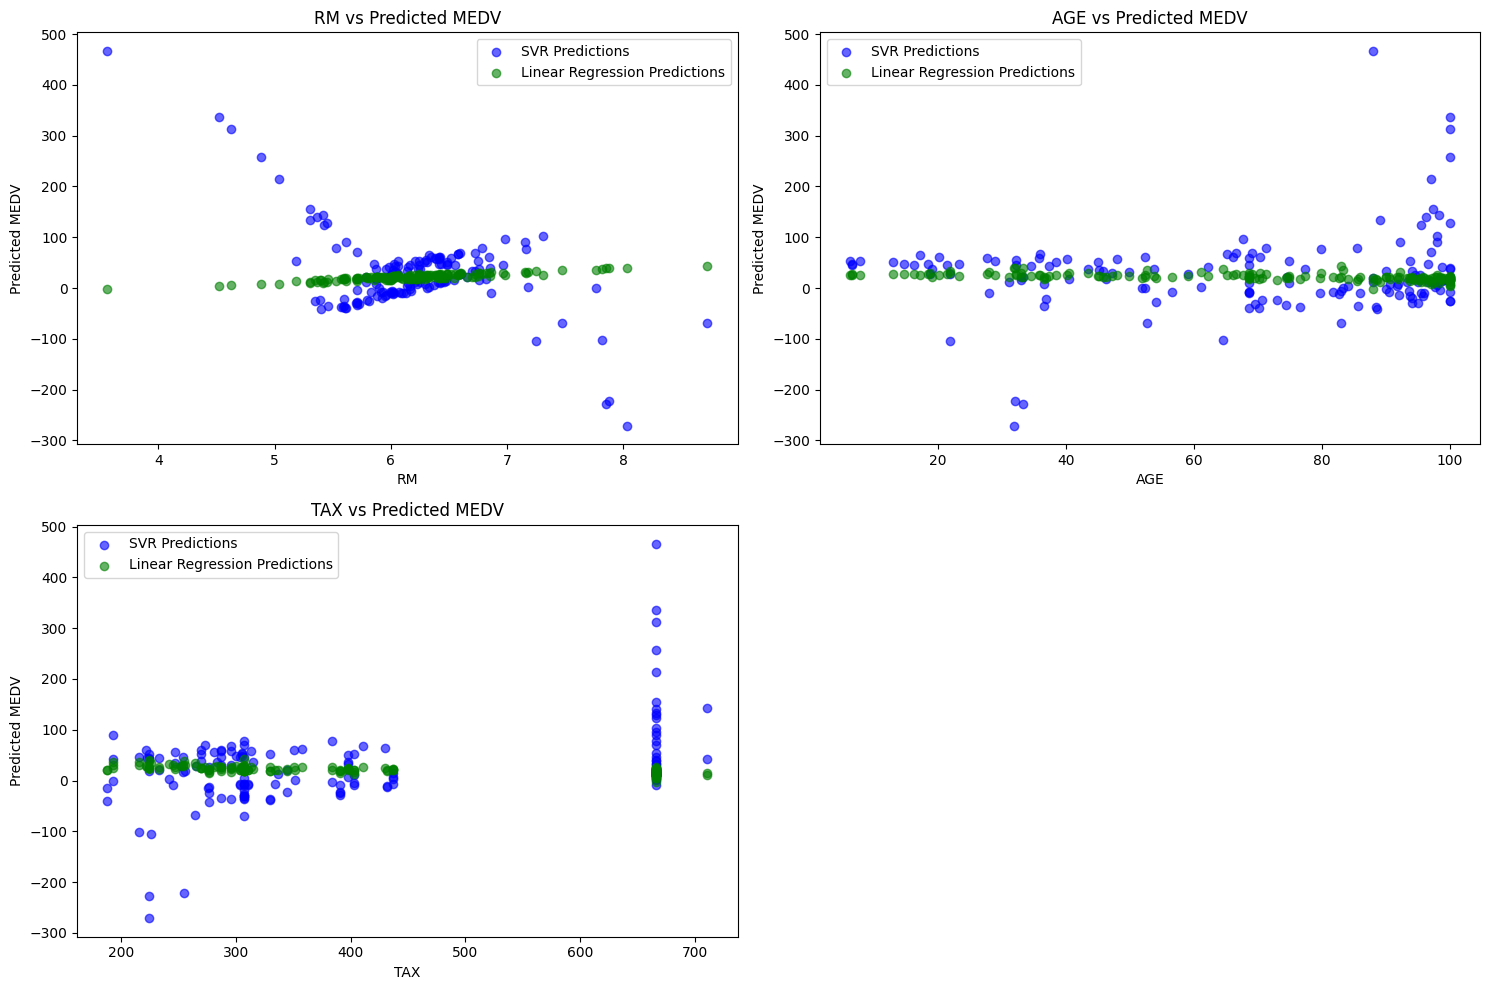

In [ ]:
# ---------------- Feature vs Predicted Plots ----------------
features = ['RM', 'AGE', 'TAX']
X_test_orig = sc_X.inverse_transform(X_test)  # get back original feature values

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)

    # Plot SVR predictions
    plt.scatter(X_test_orig[:, i], y_pred_svr_orig,
                color='blue', alpha=0.6, label='SVR Predictions')

    # Plot Linear Regression predictions
    plt.scatter(X_test_orig[:, i], y_pred_lin_orig,
                color='green', alpha=0.6, label='Linear Regression Predictions')

    plt.xlabel(feature)
    plt.ylabel("Predicted MEDV")
    plt.title(f"{feature} vs Predicted MEDV")
    plt.legend()

plt.tight_layout()
plt.show()


# **Feature vs Predicted plot using Regression Line**

This code plots feature-wise scatter plots of predicted housing prices (MEDV) against RM, AGE, and TAX, overlaying trend lines for both SVR and Linear Regression. Insight: Regression lines reveal whether models capture expected trends (e.g., more rooms → higher price, higher tax/age → lower price) and highlight differences in model behavior.

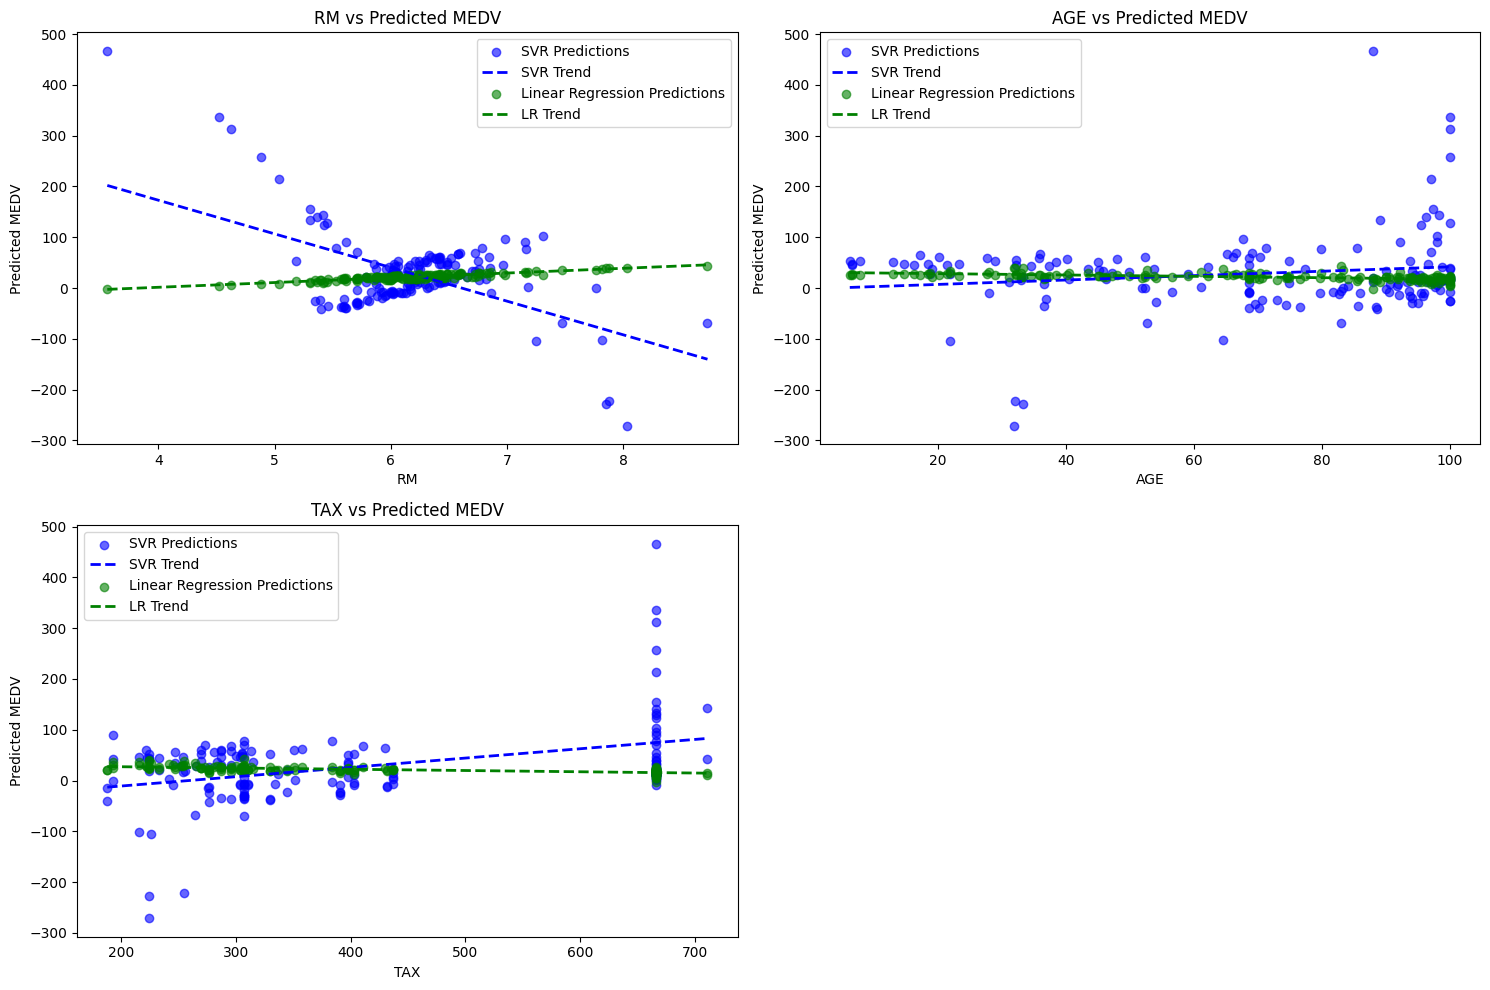

In [ ]:
# ---------------- Feature vs Predicted Plots with Regression Lines ----------------
features = ['RM', 'AGE', 'TAX']
X_test_orig = sc_X.inverse_transform(X_test)  # get back original feature values

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)

    # SVR scatter
    plt.scatter(X_test_orig[:, i], y_pred_svr_orig,
                color='blue', alpha=0.6, label='SVR Predictions')
    # Linear trend for SVR
    z_svr = np.polyfit(X_test_orig[:, i], y_pred_svr_orig.ravel(), 1)
    p_svr = np.poly1d(z_svr)
    plt.plot(sorted(X_test_orig[:, i]), p_svr(sorted(X_test_orig[:, i])),
             color='blue', linewidth=2, linestyle='--', label='SVR Trend')

    # Linear Regression scatter
    plt.scatter(X_test_orig[:, i], y_pred_lin_orig,
                color='green', alpha=0.6, label='Linear Regression Predictions')
    # Linear trend for Linear Regression
    z_lin = np.polyfit(X_test_orig[:, i], y_pred_lin_orig.ravel(), 1)
    p_lin = np.poly1d(z_lin)
    plt.plot(sorted(X_test_orig[:, i]), p_lin(sorted(X_test_orig[:, i])),
             color='green', linewidth=2, linestyle='--', label='LR Trend')

    plt.xlabel(feature)
    plt.ylabel("Predicted MEDV")
    plt.title(f"{feature} vs Predicted MEDV")
    plt.legend()

plt.tight_layout()
plt.show()



# **Feature vs Actual Predicted plots with regression line**

This code compares actual housing prices (MEDV) with predictions from SVR and Linear Regression, plotting scatter points and regression trend lines for each feature (RM, AGE, TAX). Insight: Overlaying actual and predicted trends highlights how closely each model follows real-world relationships (e.g., more rooms → higher MEDV, older houses/taxes → lower MEDV).

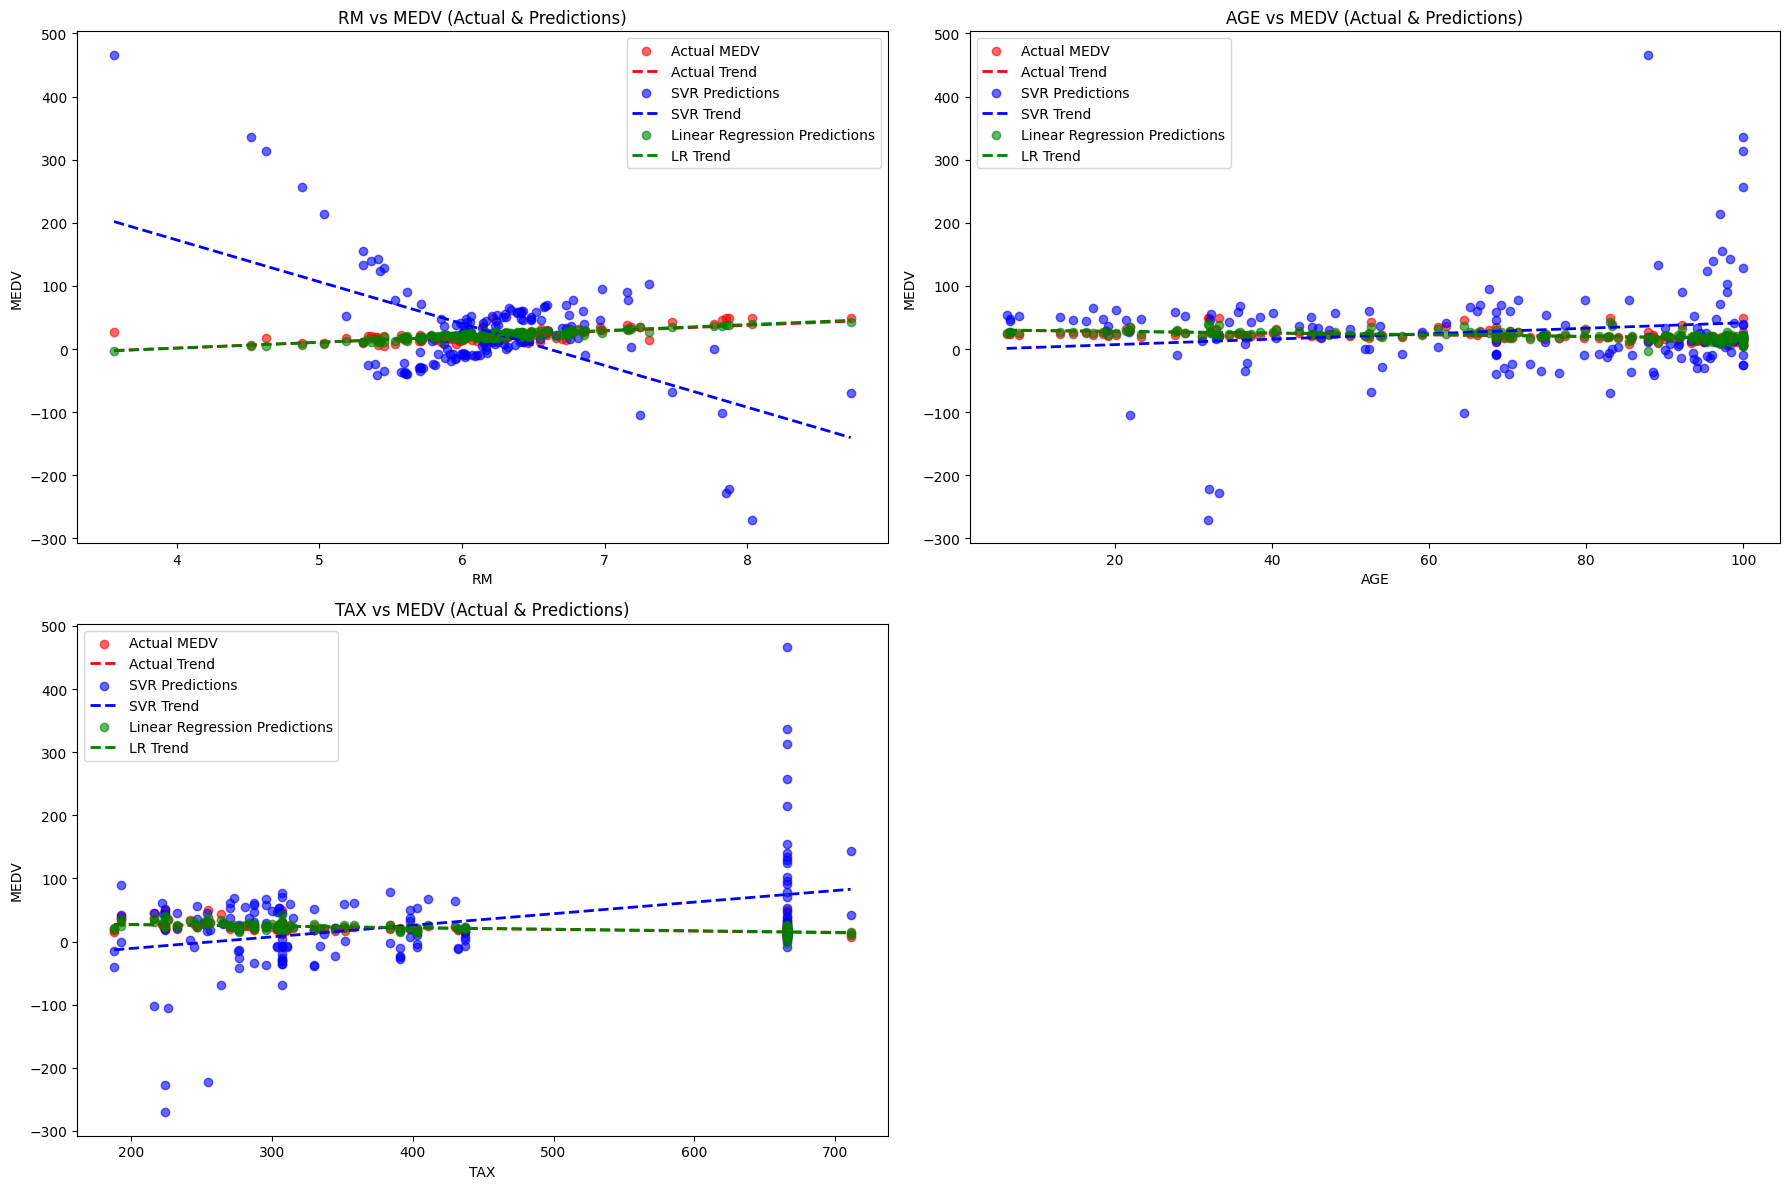

In [ ]:
# ---------------- Feature vs Actual & Predicted Plots with Regression Lines ----------------
features = ['RM', 'AGE', 'TAX']
X_test_orig = sc_X.inverse_transform(X_test)  # back to original feature values

plt.figure(figsize=(18, 12))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)

    x_vals = X_test_orig[:, i]

    # --- Actual MEDV ---
    plt.scatter(x_vals, y_test_orig, color='red', alpha=0.6, label='Actual MEDV')
    z_act = np.polyfit(x_vals, y_test_orig.ravel(), 1)
    p_act = np.poly1d(z_act)
    plt.plot(sorted(x_vals), p_act(sorted(x_vals)), color='red', linestyle='--', linewidth=2, label='Actual Trend')

    # --- SVR Predictions ---
    plt.scatter(x_vals, y_pred_svr_orig, color='blue', alpha=0.6, label='SVR Predictions')
    z_svr = np.polyfit(x_vals, y_pred_svr_orig.ravel(), 1)
    p_svr = np.poly1d(z_svr)
    plt.plot(sorted(x_vals), p_svr(sorted(x_vals)), color='blue', linestyle='--', linewidth=2, label='SVR Trend')

    # --- Linear Regression Predictions ---
    plt.scatter(x_vals, y_pred_lin_orig, color='green', alpha=0.6, label='Linear Regression Predictions')
    z_lin = np.polyfit(x_vals, y_pred_lin_orig.ravel(), 1)
    p_lin = np.poly1d(z_lin)
    plt.plot(sorted(x_vals), p_lin(sorted(x_vals)), color='green', linestyle='--', linewidth=2, label='LR Trend')

    # Labels
    plt.xlabel(feature)
    plt.ylabel("MEDV")
    plt.title(f"{feature} vs MEDV (Actual & Predictions)")
    plt.legend()

plt.tight_layout()
plt.show()
